# 07 — Evaluation & Comparison
**Project:** Semantic Book Recommender — IT4142 HUST  
**Input:**
- `reports/evaluation_baselines.json` (from nb 04 + 05)
- `data/eval/test_queries.json` (50 queries)
- `data/processed/books_with_emotions.csv` (from nb 06)
- All 3 model artifacts (`models/`, `data/chroma_db/`)

**Output:**
- `reports/figures/eval_precision_bar.png`
- `reports/figures/eval_precision_radar.png`
- `reports/figures/eval_per_category.png`
- `reports/evaluation_final.json`

Notebook này:
1. Load tất cả models + artifacts
2. Re-run evaluation trên 50 test queries (với full breakdown)
3. Tính Precision@5 và Precision@10 cho cả 3 models
4. Visualize kết quả (bar chart, radar, per-category breakdown)
5. Phân tích định tính: query nào từng model fail
6. Export final report JSON

## 0. Setup

In [3]:
import pandas as pd
import numpy as np
import pickle, json, time
import scipy.sparse as sp
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings

# Paths
DATA_PATH    = Path('data/processed/books_with_emotions.csv')
EVAL_PATH    = Path('data/eval/test_queries.json')
MODEL_PATH   = Path('models')
CHROMA_PATH  = Path('data/chroma_db')
REPORT_PATH  = Path('reports')
FIGURE_PATH  = Path('reports/figures')
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 150,
    'figure.facecolor': 'white', 'axes.facecolor': '#F9F9F9',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13, 'axes.labelsize': 11,
})

MODEL_COLORS = {
    'TF-IDF'  : '#6B8CBA',
    'BM25'    : '#F4A261',
    'Semantic': '#2A9D8F',
}

print('Setup OK')

Setup OK


## 1. Load Data & Test Queries

In [4]:
df = pd.read_csv(DATA_PATH)
print(f'Books loaded: {len(df):,}')

with open(EVAL_PATH) as f:
    test_queries = json.load(f)
print(f'Test queries: {len(test_queries)}')

Books loaded: 6,385
Test queries: 50


## 2. Load All Models

In [5]:
# --- TF-IDF ---
print('Loading TF-IDF...')
with open(MODEL_PATH / 'tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)
tfidf_matrix = sp.load_npz(MODEL_PATH / 'tfidf_matrix.npz')
print(f'  TF-IDF matrix: {tfidf_matrix.shape}')

# --- BM25 ---
print('Loading BM25...')
with open(MODEL_PATH / 'bm25_index.pkl', 'rb') as f:
    bm25 = pickle.load(f)
print(f'  BM25 corpus size: {bm25.corpus_size}')

# --- Semantic (BGE-small + ChromaDB) ---
print('Loading BGE-small...')
MODEL_NAME = 'BAAI/bge-small-en-v1.5'
embed_model = SentenceTransformer(MODEL_NAME)

print('Loading ChromaDB...')
chroma_client = chromadb.PersistentClient(
    path=str(CHROMA_PATH),
    settings=Settings(anonymized_telemetry=False),
)
collection = chroma_client.get_collection('books')
print(f'  ChromaDB count: {collection.count():,}')

print('\nAll models loaded ✓')

Loading TF-IDF...
  TF-IDF matrix: (6385, 15000)
Loading BM25...
  BM25 corpus size: 6385
Loading BGE-small...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8416.86it/s]


Loading ChromaDB...
  ChromaDB count: 6,385

All models loaded ✓


## 3. Search Functions

In [6]:
BGE_PREFIX = 'Represent this sentence for searching relevant passages: '

def search_tfidf(query: str, top_k: int = 10) -> pd.DataFrame:
    q_vec = vectorizer.transform([query])
    scores = cosine_similarity(q_vec, tfidf_matrix).flatten()
    idx = np.argsort(scores)[::-1][:top_k]
    res = df.iloc[idx][['isbn13', 'title', 'categories']].copy()
    res['score'] = scores[idx]
    return res.reset_index(drop=True)


def search_bm25(query: str, top_k: int = 10) -> pd.DataFrame:
    scores = bm25.get_scores(query.lower().split())
    idx = np.argsort(scores)[::-1][:top_k]
    res = df.iloc[idx][['isbn13', 'title', 'categories']].copy()
    res['score'] = scores[idx]
    return res.reset_index(drop=True)


def search_semantic(query: str, top_k: int = 10) -> pd.DataFrame:
    q_emb = embed_model.encode([BGE_PREFIX + query], normalize_embeddings=True)
    results = collection.query(
        query_embeddings=q_emb.tolist(),
        n_results=top_k,
        include=['metadatas', 'distances'],
    )
    rows = [
        {
            'isbn13'    : results['ids'][0][i],
            'title'     : results['metadatas'][0][i].get('title', ''),
            'categories': results['metadatas'][0][i].get('categories', ''),
            'score'     : round(1 - results['distances'][0][i], 4),
        }
        for i in range(len(results['ids'][0]))
    ]
    return pd.DataFrame(rows)


SEARCH_FNS = {
    'TF-IDF'  : search_tfidf,
    'BM25'    : search_bm25,
    'Semantic': search_semantic,
}
print('Search functions ready')

Search functions ready


## 4. Evaluation Logic

In [7]:
def is_relevant(book_category: str, relevant_categories: list) -> bool:
    if not isinstance(book_category, str):
        return False
    book_lower = book_category.lower()
    return any(
        rc.lower() in book_lower or book_lower in rc.lower()
        for rc in relevant_categories
    )


def precision_at_k(results_df: pd.DataFrame, relevant_categories: list, k: int) -> float:
    hits = results_df.head(k)['categories'].apply(
        lambda c: is_relevant(c, relevant_categories)
    ).sum()
    return hits / k


K_VALUES = [5, 10]

print('Evaluation functions ready')

Evaluation functions ready


## 5. Run Full Evaluation (All 3 Models × 50 Queries)

In [8]:
eval_records = []  # one row per (model, query)

for model_name, search_fn in SEARCH_FNS.items():
    print(f'Evaluating {model_name}...', end=' ', flush=True)
    t0 = time.time()
    for q in test_queries:
        results = search_fn(q['query'], top_k=max(K_VALUES))
        record = {
            'model'  : model_name,
            'query'  : q['query'],
            'genres' : ', '.join(q['relevant_categories']),
        }
        for k in K_VALUES:
            record[f'P@{k}'] = round(precision_at_k(results, q['relevant_categories'], k), 4)
        eval_records.append(record)
    print(f'done ({time.time()-t0:.1f}s)')

df_eval = pd.DataFrame(eval_records)
print(f'\nTotal eval rows: {len(df_eval)}')
df_eval.head(6)

Evaluating TF-IDF... done (0.2s)
Evaluating BM25... done (0.3s)
Evaluating Semantic... done (0.8s)

Total eval rows: 150


,model,query,genres,P@5,P@10
0,TF-IDF,a heartbreaking story about family secrets in ...,"Fiction, Literary Fiction, Family & Relationships",0.6,0.6
1,TF-IDF,coming of age story with complex friendships,"Fiction, Young Adult Fiction, Coming of Age",0.2,0.2
2,TF-IDF,a novel about identity and belonging in a fore...,"Fiction, Literary Fiction, Cultural",0.4,0.7
3,TF-IDF,interconnected stories about love and loss in ...,"Fiction, Short Stories, Literary Fiction",0.8,0.8
4,TF-IDF,a story about grief and moving on after tragedy,"Fiction, Literary Fiction, Family & Relationships",0.6,0.7
5,TF-IDF,a thriller set in Japan with a detective prota...,"Mystery & Detective, Thriller, Fiction, Crime",0.8,0.7


## 6. Summary Table — Mean Precision@K

In [9]:
summary = (
    df_eval
    .groupby('model')[['P@5', 'P@10']]
    .mean()
    .round(4)
    .reindex(['TF-IDF', 'BM25', 'Semantic'])
)

summary['Type'] = ['Sparse baseline', 'Sparse baseline', 'Dense (proposed)']
summary = summary[['Type', 'P@5', 'P@10']]

print('=' * 55)
print('  RETRIEVAL EVALUATION — Precision@K (50 test queries)')
print('=' * 55)
print(summary.to_string())
print('=' * 55)

  RETRIEVAL EVALUATION — Precision@K (50 test queries)
                      Type    P@5   P@10
model                                   
TF-IDF     Sparse baseline  0.616  0.606
BM25       Sparse baseline  0.628  0.594
Semantic  Dense (proposed)  0.580  0.574


## 7. Plot A — Grouped Bar Chart (P@5 and P@10)

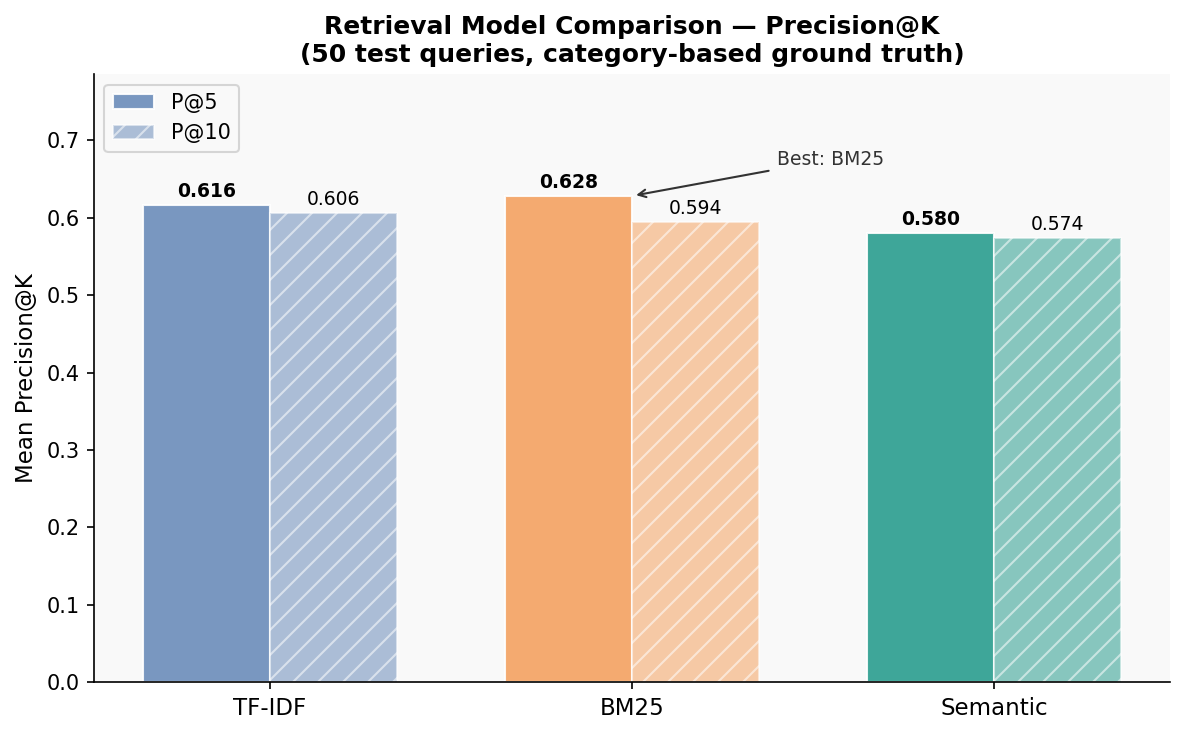

Saved: eval_precision_bar.png


In [10]:
models = ['TF-IDF', 'BM25', 'Semantic']
p5_vals  = [summary.loc[m, 'P@5']  for m in models]
p10_vals = [summary.loc[m, 'P@10'] for m in models]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, p5_vals,  width, label='P@5',
               color=[MODEL_COLORS[m] for m in models], alpha=0.9, edgecolor='white')
bars2 = ax.bar(x + width/2, p10_vals, width, label='P@10',
               color=[MODEL_COLORS[m] for m in models], alpha=0.55, edgecolor='white',
               hatch='//')

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Mean Precision@K')
ax.set_title('Retrieval Model Comparison — Precision@K\n(50 test queries, category-based ground truth)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, min(1.0, max(p5_vals + p10_vals) * 1.25))
ax.legend(loc='upper left')

# Annotation for best model
best_model = models[np.argmax(p5_vals)]
ax.annotate(f'Best: {best_model}', xy=(np.argmax(p5_vals), max(p5_vals)),
            xytext=(np.argmax(p5_vals) + 0.4, max(p5_vals) + 0.04),
            arrowprops=dict(arrowstyle='->', color='#333'),
            fontsize=9, color='#333')

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'eval_precision_bar.png')
plt.show()
print('Saved: eval_precision_bar.png')

## 8. Plot B — Radar Chart

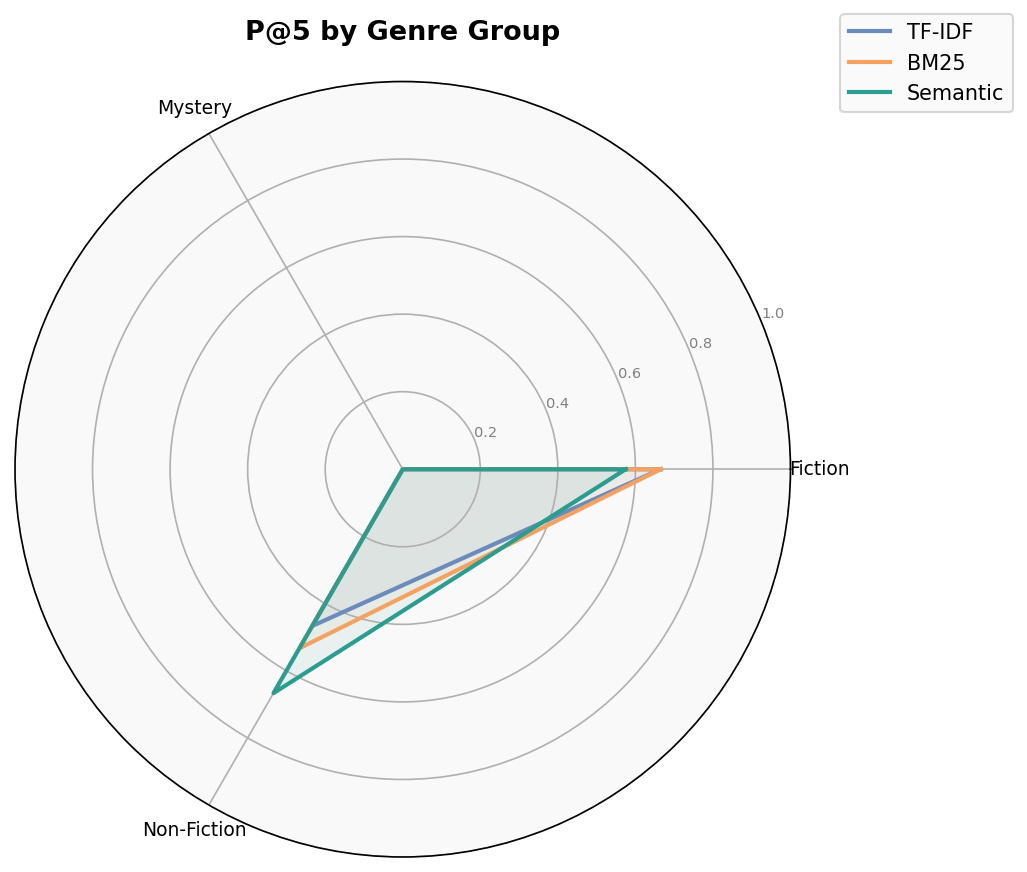

Saved: eval_precision_radar.png


In [11]:
# Genre groups for radar axes
GENRE_GROUPS = {
    'Fiction'     : ['Fiction', 'Literary Fiction'],
    'Mystery'     : ['Mystery & Detective', 'Crime', 'Thriller'],
    'Sci-Fi'      : ['Science Fiction'],
    'Fantasy'     : ['Fantasy'],
    'Romance'     : ['Romance'],
    'Non-Fiction' : ['Self-Help', 'Business & Economics', 'Biography & Autobiography', 'History'],
    'Horror'      : ['Horror'],
    'YA/Children' : ['Young Adult Fiction', 'Juvenile Fiction'],
}

def assign_genre_group(relevant_cats: str) -> str:
    cats_lower = relevant_cats.lower()
    for group, keywords in GENRE_GROUPS.items():
        if any(k.lower() in cats_lower for k in keywords):
            return group
    return 'Other'

df_eval['genre_group'] = df_eval['genres'].apply(assign_genre_group)

radar_data = (
    df_eval
    .groupby(['model', 'genre_group'])['P@5']
    .mean()
    .unstack(fill_value=0)
    .reindex(index=['TF-IDF', 'BM25', 'Semantic'])
)

genre_labels = [g for g in radar_data.columns if g != 'Other']
N = len(genre_labels)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for model in ['TF-IDF', 'BM25', 'Semantic']:
    values = [radar_data.loc[model, g] if g in radar_data.columns else 0
              for g in genre_labels]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=model, color=MODEL_COLORS[model])
    ax.fill(angles, values, alpha=0.08, color=MODEL_COLORS[model])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(genre_labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7, color='grey')
ax.set_title('P@5 by Genre Group', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'eval_precision_radar.png', bbox_inches='tight')
plt.show()
print('Saved: eval_precision_radar.png')

## 9. Plot C — Per-Category Heatmap

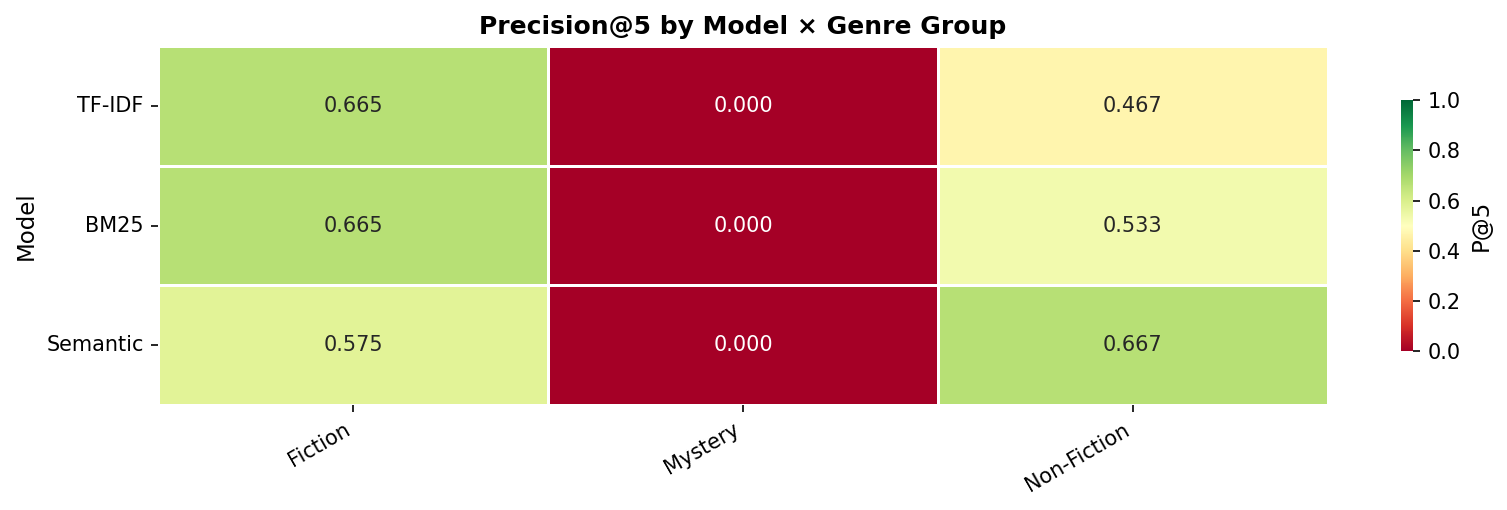

Saved: eval_per_category.png


In [12]:
pivot_p5 = (
    df_eval[df_eval['genre_group'] != 'Other']
    .groupby(['model', 'genre_group'])['P@5']
    .mean()
    .unstack()
    .reindex(index=['TF-IDF', 'BM25', 'Semantic'])
    .round(3)
)

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(
    pivot_p5,
    ax=ax,
    annot=True, fmt='.3f',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.6,
    cbar_kws={'shrink': 0.7, 'label': 'P@5'},
)
ax.set_title('Precision@5 by Model × Genre Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Model')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_PATH / 'eval_per_category.png', bbox_inches='tight')
plt.show()
print('Saved: eval_per_category.png')

## 10. Qualitative Analysis — Best & Worst Queries per Model

In [13]:
for model in ['TF-IDF', 'BM25', 'Semantic']:
    model_df = df_eval[df_eval['model'] == model].sort_values('P@5', ascending=False)
    print(f'\n--- {model} ---')
    print('TOP 3 queries (highest P@5):')
    for _, row in model_df.head(3).iterrows():
        print(f"  P@5={row['P@5']:.2f}  {row['query'][:70]}")
    print('BOTTOM 3 queries (lowest P@5):')
    for _, row in model_df.tail(3).iterrows():
        print(f"  P@5={row['P@5']:.2f}  {row['query'][:70]}")


--- TF-IDF ---
TOP 3 queries (highest P@5):
  P@5=1.00  a world where dragons and humans coexist
  P@5=1.00  technology and ethics in a near-future surveillance state
  P@5=1.00  leadership lessons from successful business executives
BOTTOM 3 queries (lowest P@5):
  P@5=0.20  epic fantasy with magic systems and a chosen hero
  P@5=0.00  a crime novel with an unreliable narrator
  P@5=0.00  the science of motivation and achieving long-term goals

--- BM25 ---
TOP 3 queries (highest P@5):
  P@5=1.00  a novel about identity and belonging in a foreign country
  P@5=1.00  interconnected stories about love and loss in a small town
  P@5=1.00  a story about grief and moving on after tragedy
BOTTOM 3 queries (lowest P@5):
  P@5=0.20  a philosophical novel questioning the meaning of existence
  P@5=0.20  the science of motivation and achieving long-term goals
  P@5=0.00  a crime novel with an unreliable narrator

--- Semantic ---
TOP 3 queries (highest P@5):
  P@5=1.00  a cookbook with traditi

## 11. Win/Loss Analysis — Semantic vs Baselines

In [14]:
# Pivot to compare per-query
pivot = df_eval.pivot(index='query', columns='model', values='P@5')

def win_loss(col_a, col_b, df):
    wins   = (df[col_a] > df[col_b]).sum()
    ties   = (df[col_a] == df[col_b]).sum()
    losses = (df[col_a] < df[col_b]).sum()
    return wins, ties, losses

for baseline in ['TF-IDF', 'BM25']:
    w, t, l = win_loss('Semantic', baseline, pivot)
    print(f'Semantic vs {baseline:7s}  →  Win: {w}  Tie: {t}  Loss: {l}  (out of 50 queries)')

print()
# Queries where Semantic fails but TF-IDF wins
if 'TF-IDF' in pivot.columns and 'Semantic' in pivot.columns:
    semantic_fails = pivot[pivot['Semantic'] < pivot['TF-IDF']].index.tolist()
    print(f'Queries where Semantic < TF-IDF ({len(semantic_fails)}):')
    for q in semantic_fails[:5]:
        print(f'  {q[:80]}')

Semantic vs TF-IDF   →  Win: 18  Tie: 11  Loss: 21  (out of 50 queries)
Semantic vs BM25     →  Win: 18  Tie: 11  Loss: 21  (out of 50 queries)

Queries where Semantic < TF-IDF (21):
  a deeply sad story about death and remembrance
  a heartbreaking story about family secrets in rural America
  a joyful story about unlikely friendships overcoming differences
  a novel about identity and belonging in a foreign country
  a space opera with epic battles across multiple planets


## 12. Speed Benchmark

In [15]:
BENCH_QUERY = 'a heartbreaking story about family secrets'
REPS = 10

speed_results = {}
for model_name, fn in SEARCH_FNS.items():
    # Warm-up
    fn(BENCH_QUERY, top_k=10)
    # Benchmark
    t0 = time.time()
    for _ in range(REPS):
        fn(BENCH_QUERY, top_k=10)
    elapsed_ms = (time.time() - t0) / REPS * 1000
    speed_results[model_name] = round(elapsed_ms, 1)
    print(f'{model_name:10s}: {elapsed_ms:.1f} ms/query')

print(f'\nFastest: {min(speed_results, key=speed_results.get)}')

TF-IDF    : 2.9 ms/query
BM25      : 9.8 ms/query
Semantic  : 10.9 ms/query

Fastest: TF-IDF


## 13. Final Report — Save to JSON

In [16]:
final_report = {
    'experiment': 'Semantic Book Recommender — Retrieval Evaluation',
    'course'    : 'IT4142 HUST',
    'num_queries': len(test_queries),
    'corpus_size': len(df),
    'embedding_model': MODEL_NAME,
    'evaluation_metric': 'Precision@K (category-based proxy relevance)',
    'results': {
        model: {
            'P@5' : float(summary.loc[model, 'P@5']),
            'P@10': float(summary.loc[model, 'P@10']),
            'type': summary.loc[model, 'Type'],
            'avg_latency_ms': speed_results.get(model),
        }
        for model in ['TF-IDF', 'BM25', 'Semantic']
    },
    'per_query_breakdown': df_eval.to_dict(orient='records'),
    'figures': [
        'reports/figures/eval_precision_bar.png',
        'reports/figures/eval_precision_radar.png',
        'reports/figures/eval_per_category.png',
    ]
}

with open(REPORT_PATH / 'evaluation_final.json', 'w') as f:
    json.dump(final_report, f, indent=2)
print('Saved: reports/evaluation_final.json')

Saved: reports/evaluation_final.json


## 14. Print Final Summary for Report

In [17]:
print('\n' + '='*60)
print('  FINAL RESULTS — Copy vào báo cáo')
print('='*60)
print(f'  Corpus size   : {len(df):,} books')
print(f'  Test queries  : {len(test_queries)}')
print(f'  Eval metric   : Precision@K (category proxy)')
print()
print(f'  {"Model":<22} {"Type":<20} {"P@5":>6} {"P@10":>6} {"ms/q":>6}')
print(f'  {"-"*22} {"-"*20} {"-"*6} {"-"*6} {"-"*6}')
for m in ['TF-IDF', 'BM25', 'Semantic']:
    marker = ' ✓' if m == 'Semantic' else '  '
    print(f'{marker} {m:<22} {summary.loc[m,"Type"]:<20} '
          f'{summary.loc[m,"P@5"]:>6.4f} {summary.loc[m,"P@10"]:>6.4f} '
          f'{speed_results.get(m,"?"):>6}')
print('='*60)


  FINAL RESULTS — Copy vào báo cáo
  Corpus size   : 6,385 books
  Test queries  : 50
  Eval metric   : Precision@K (category proxy)

  Model                  Type                    P@5   P@10   ms/q
  ---------------------- -------------------- ------ ------ ------
   TF-IDF                 Sparse baseline      0.6160 0.6060    2.9
   BM25                   Sparse baseline      0.6280 0.5940    9.8
 ✓ Semantic               Dense (proposed)     0.5800 0.5740   10.9


---
## Done ✓ — All 7 notebooks complete

**Artifacts produced:**
- `reports/figures/eval_precision_bar.png` — grouped bar P@5 / P@10
- `reports/figures/eval_precision_radar.png` — radar chart by genre
- `reports/figures/eval_per_category.png` — heatmap model × genre
- `reports/evaluation_final.json` — full structured report

**Next steps:**
- `backend/main.py` — FastAPI serving all 3 models
- `frontend/` — React UI consuming the API